In [1]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

import gymnasium as gym
from utils_old import (
    AgentRand,
    AgentQL,
    AgentSARSA,
    plot_training_stats,
    create_grids,
    create_plots
)

In [2]:
env = gym.make('Blackjack-v1', natural=False, sab=False)

In [3]:
# hyperparameters
learning_rate = 0.01
n_episodes = 100_000
start_epsilon = 1.0
epsilon_decay = start_epsilon / (n_episodes / 2)  # reduce the exploration over time
final_epsilon = 0.1

agent_ql = AgentQL(
    env=env,
    learning_rate=learning_rate,
    initial_epsilon=start_epsilon,
    epsilon_decay=epsilon_decay,
    final_epsilon=final_epsilon,
)

In [4]:
env = gym.wrappers.RecordEpisodeStatistics(env, buffer_length=n_episodes)
for episode in tqdm(range(n_episodes)):
    obs, info = env.reset()
    done = False

    # play one episode
    while not done:
        action = agent_ql.get_action(env, obs)
        next_obs, reward, terminated, truncated, info = env.step(action)

        # update the agent
        agent_ql.update(obs, action, reward, terminated, next_obs)

        # update if the environment is done and the current obs
        done = terminated or truncated
        obs = next_obs

    agent_ql.decay_epsilon()

100%|██████████| 100000/100000 [00:11<00:00, 8668.87it/s]


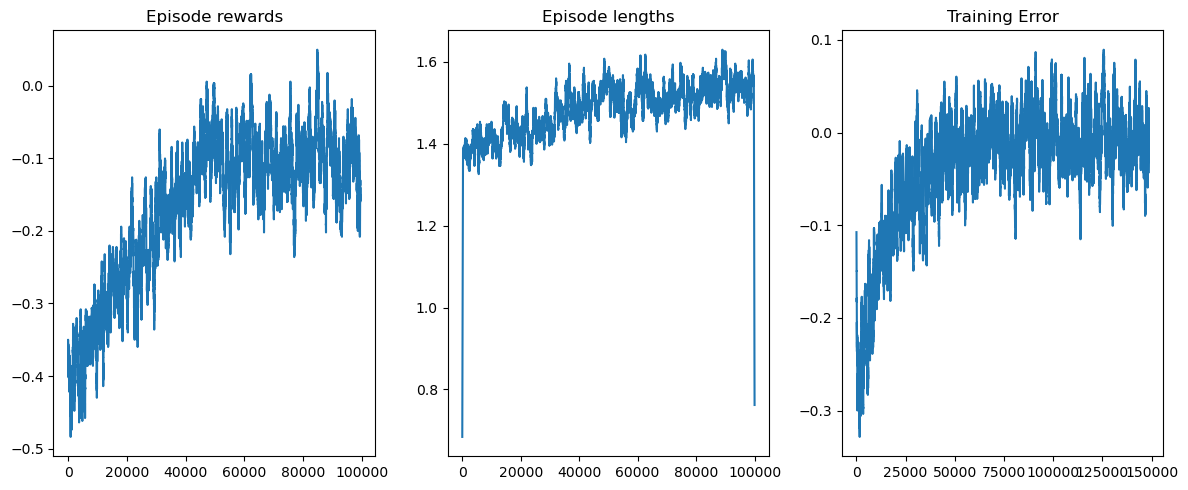

In [5]:
plot_training_stats(env, agent_ql)

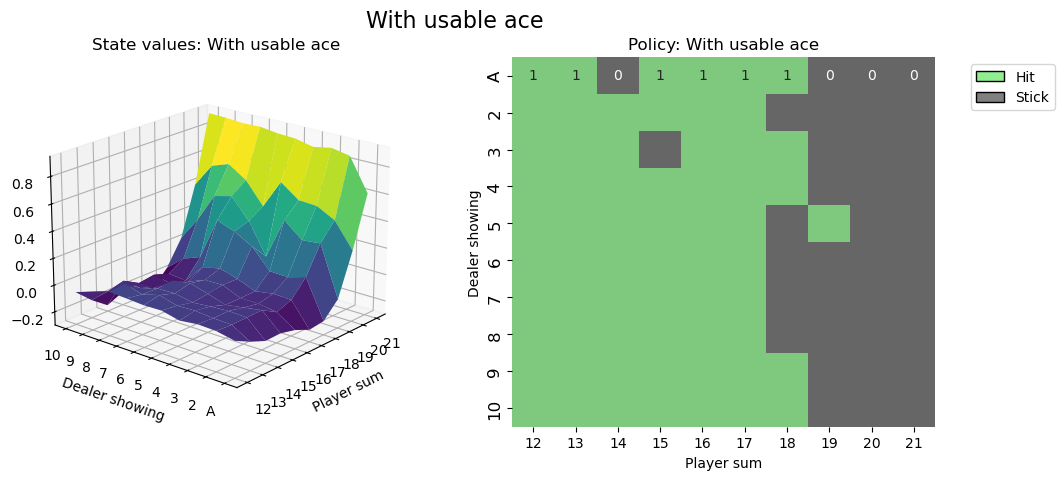

In [6]:
# state values & policy with usable ace (ace counts as 11)
value_grid, policy_grid = create_grids(agent_ql, usable_ace=True)
fig1 = create_plots(value_grid, policy_grid, title="With usable ace")
plt.show()

In [7]:
env = gym.make('Blackjack-v1', natural=False, sab=False)

In [8]:
# hyperparameters
learning_rate = 0.01
n_episodes = 100_000
start_epsilon = 1.0
epsilon_decay = start_epsilon / (n_episodes / 2)  # reduce the exploration over time
final_epsilon = 0.1

agent_sarsa = AgentSARSA(
    env=env,
    learning_rate=learning_rate,
    initial_epsilon=start_epsilon,
    epsilon_decay=epsilon_decay,
    final_epsilon=final_epsilon,
)

In [9]:
env = gym.wrappers.RecordEpisodeStatistics(env, buffer_length=n_episodes)
for episode in tqdm(range(n_episodes)):
    obs, info = env.reset()
    action = agent_sarsa.get_action(env, obs)
    done = False

    while not done:
        # Take a step in the environment
        next_obs, reward, terminated, truncated, info = env.step(action)
        next_action = agent_sarsa.get_action(env, next_obs)

        # Update the agent using the SARSA update rule
        agent_sarsa.update(obs, action, reward, terminated, next_obs, next_action)

        # Update the observation and action for the next iteration
        obs, action = next_obs, next_action

        # Check if the episode has ended
        done = terminated or truncated

    # Decay epsilon after each episode
    agent_sarsa.decay_epsilon()

100%|██████████| 100000/100000 [00:11<00:00, 9000.66it/s]


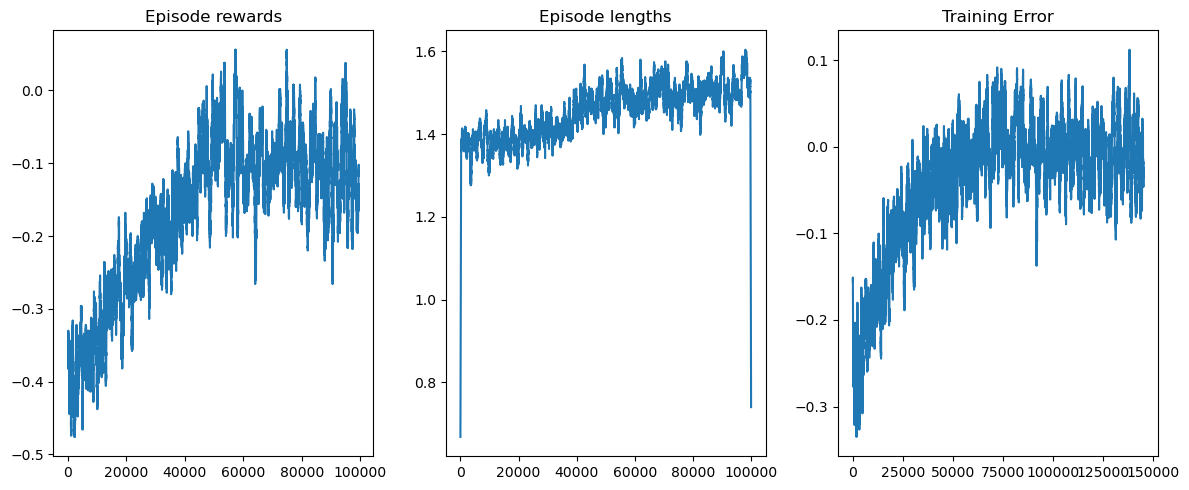

In [10]:
plot_training_stats(env, agent_sarsa)

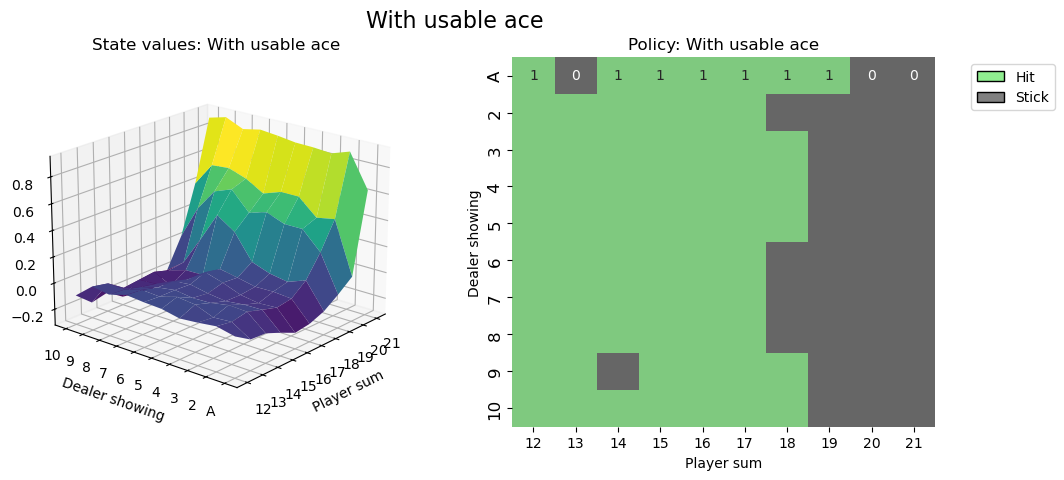

In [11]:
# state values & policy with usable ace (ace counts as 11)
value_grid, policy_grid = create_grids(agent_sarsa, usable_ace=True)
fig1 = create_plots(value_grid, policy_grid, title="With usable ace")
plt.show()